In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)


True

## 1. Load & Inspect Data

In [3]:
data = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
data.columns = ['Target', 'Text']

print('Shape:', data.shape)
print('\nClass distribution:')
print(data['Target'].value_counts())
print('\nNull values:', data.isnull().sum().sum())


Shape: (5572, 2)

Class distribution:
Target
ham     4825
spam     747
Name: count, dtype: int64

Null values: 0


## 2. Text Preprocessing

In [4]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

SPAM_WORDS = {
    'free', 'win', 'winner', 'won', 'prize', 'award', 'gift',
    'reward', 'bonus', 'jackpot', 'lottery', 'sweepstake', 'congratulations',
    'selected', 'chosen', 'lucky', 'giveaway',
    'cash', 'money', 'dollar', 'pounds', 'euro', 'salary', 'income',
    'profit', 'earn', 'earning', 'investment', 'loan', 'credit', 'debt',
    'mortgage', 'insurance', 'refund', 'voucher', 'discount', 'coupon',
    'deal', 'offer', 'save', 'saving',
    'urgent', 'immediately', 'instant', 'now', 'today', 'tonight',
    'hurry', 'rush', 'limited', 'expire', 'deadline', 'final', 'last',
    'warning', 'alert', 'attention', 'important', 'critical', 'act',
    'account', 'password', 'login', 'verify', 'verification', 'confirm',
    'suspended', 'blocked', 'compromised', 'unauthorized', 'security',
    'update', 'information', 'details', 'click', 'link', 'access',
    'validate', 'authenticate',
    'call', 'contact', 'reply', 'text', 'sms', 'phone', 'mobile',
    'number', 'toll', 'helpline', 'customer', 'service', 'support',
    'sex', 'adult', 'xxx', 'dating', 'single', 'meet', 'hot',
    'horny', 'explicit', 'nude',
    'subscribe', 'subscription', 'trial', 'cancel', 'charge',
    'billing', 'invoice', 'receipt', 'order', 'delivery',
    'claim', 'guaranteed', 'promise', '100', 'percent', 'risk',
    'opportunity', 'exclusive', 'special', 'vip', 'member', 'membership',
}

def preprocess(text: str) -> str:
    tokens = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

def keyword_score(text: str) -> int:
    tokens = set(re.sub(r'[^a-zA-Z]', ' ', text).lower().split())
    return sum(1 for w in SPAM_WORDS if w in tokens)

def caps_ratio(text: str) -> float:
    letters = [c for c in text if c.isalpha()]
    return sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0

def exclamation_count(text: str) -> int:
    return text.count('!')

def has_url(text: str) -> int:
    return int(bool(re.search(r'http|www\.|.com|.net|.org', text, re.I)))

def has_phone(text: str) -> int:
    return int(bool(re.search(r'\b\d{5,}\b|\(\d{3}\)', text)))

data['Clean_Text']        = data['Text'].apply(preprocess)
data['char_len']          = data['Clean_Text'].apply(len)
data['word_count']        = data['Clean_Text'].apply(lambda x: len(x.split()))
data['keyword_score']     = data['Text'].apply(keyword_score)
data['caps_ratio']        = data['Text'].apply(caps_ratio)
data['exclamation_count'] = data['Text'].apply(exclamation_count)
data['has_url']           = data['Text'].apply(has_url)
data['has_phone']         = data['Text'].apply(has_phone)

NUM_FEATURES = ['char_len', 'word_count', 'keyword_score',
                'caps_ratio', 'exclamation_count', 'has_url', 'has_phone']

print(data[['Target'] + NUM_FEATURES].groupby(data['Target']).mean().round(3))


        char_len  word_count  keyword_score  caps_ratio  exclamation_count  \
Target                                                                       
ham       43.060       7.936          0.334       0.081              0.174   
spam      87.341      15.581          3.161       0.166              0.726   

        has_url  has_phone  
Target                      
ham       0.097      0.001  
spam      0.272      0.754  


## 3. Encode Labels & Stratified Split

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y  = le.fit_transform(data['Target'])   # ham=0, spam=1

X_text = data['Clean_Text']
X_num  = data[NUM_FEATURES].values

(X_text_train, X_text_test,
 X_num_train,  X_num_test,
 y_train,      y_test) = train_test_split(
    X_text, X_num, y,
    test_size=0.2, random_state=42, stratify=y
)

# Validation split carved from training set
(X_text_tr, X_text_val,
 X_num_tr,  X_num_val,
 y_tr,      y_val) = train_test_split(
    X_text_train, X_num_train, y_train,
    test_size=0.15, random_state=42, stratify=y_train
)

print(f'Train (full) : {len(y_train)}')
print(f'Train (tr)   : {len(y_tr)}')
print(f'Val          : {len(y_val)}')
print(f'Test         : {len(y_test)}')
print(f'Train spam %: {y_tr.mean():.2%}  Val spam %: {y_val.mean():.2%}  Test spam %: {y_test.mean():.2%}')


Train (full) : 4457
Train (tr)   : 3788
Val          : 669
Test         : 1115
Train spam %: 13.41%  Val spam %: 13.45%  Test spam %: 13.36%


## 4. Feature Pipeline (No Leakage)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=4000, ngram_range=(1, 2),
                                  min_df=3, max_df=0.7), 'text'),
        ('num',   MinMaxScaler(), NUM_FEATURES),
    ],
    sparse_threshold=0.0
)

def make_df(X_text_arr, X_num_arr):
    """Wrap text + numeric features into a single DataFrame."""
    df = pd.DataFrame(
        X_num_arr if isinstance(X_num_arr, np.ndarray) else X_num_arr.values,
        columns=NUM_FEATURES
    )
    df['text'] = X_text_arr.values if hasattr(X_text_arr, 'values') else X_text_arr
    return df

# tr split — used for cross-validation (sizes align with y_tr)
train_df = make_df(X_text_tr,  pd.DataFrame(X_num_tr,    columns=NUM_FEATURES))
# full training set — used for final model fitting (sizes align with y_train)
full_train_df = make_df(X_text_train, pd.DataFrame(X_num_train, columns=NUM_FEATURES))
val_df        = make_df(X_text_val,   pd.DataFrame(X_num_val,   columns=NUM_FEATURES))
test_df       = make_df(X_text_test,  pd.DataFrame(X_num_test,  columns=NUM_FEATURES))

print('Shapes — train_df:', train_df.shape, '| y_tr:', y_tr.shape)
print('Shapes — full_train_df:', full_train_df.shape, '| y_train:', y_train.shape)
print('Shapes — val_df:', val_df.shape, '| y_val:', y_val.shape)
print('Shapes — test_df:', test_df.shape, '| y_test:', y_test.shape)


Shapes — train_df: (3788, 8) | y_tr: (3788,)
Shapes — full_train_df: (4457, 8) | y_train: (4457,)
Shapes — val_df: (669, 8) | y_val: (669,)
Shapes — test_df: (1115, 8) | y_test: (1115,)


## 5. Define Models

In [7]:
from sklearn.naive_bayes  import MultinomialNB
from sklearn.svm          import SVC
from sklearn.ensemble     import RandomForestClassifier, VotingClassifier

def build_pipeline(classifier):
    return Pipeline([
        ('features', preprocessor),
        ('selector', SelectKBest(chi2, k=2000)),
        ('clf',      classifier),
    ])

base_models = {
    'Naive Bayes':   build_pipeline(MultinomialNB(alpha=0.5)),
    'SVM':           build_pipeline(SVC(C=1, kernel='linear',
                                        probability=True,
                                        class_weight='balanced',
                                        random_state=42)),
    'Random Forest': build_pipeline(RandomForestClassifier(
                                        n_estimators=200, max_depth=20,
                                        class_weight='balanced',
                                        random_state=42, n_jobs=-1)),
}


## 6. Train & Evaluate (Train / Val / Test)

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in base_models.items():
    # ── FIX: CV uses train_df / y_tr (sizes match: both are the tr split) ──
    cv_scores = cross_val_score(pipe, train_df, y_tr,
                                cv=cv, scoring='accuracy', n_jobs=-1)

    # ── FIX: final fit uses full_train_df / y_train (full training set) ──
    pipe.fit(full_train_df, y_train)

    y_pred_val  = pipe.predict(val_df)
    y_proba_val = pipe.predict_proba(val_df)[:, 1]

    y_pred_test  = pipe.predict(test_df)
    y_proba_test = pipe.predict_proba(test_df)[:, 1]

    results[name] = {
        'Train Acc': pipe.score(full_train_df, y_train),
        'Val Acc':   accuracy_score(y_val,  y_pred_val),
        'Val F1':    f1_score(y_val,  y_pred_val, zero_division=0),
        'CV Acc':    cv_scores.mean(),
        'CV Std':    cv_scores.std(),
        'Test Acc':  accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_test, zero_division=0),
        'F1':        f1_score(y_test, y_pred_test, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_proba_test),
        '_y_pred':   y_pred_test,
        '_y_proba':  y_proba_test,
    }

summary_cols = ['Train Acc', 'Val Acc', 'Val F1', 'CV Acc', 'CV Std',
                'Test Acc', 'Precision', 'Recall', 'F1', 'AUC']

summary = pd.DataFrame(results).T[summary_cols].astype(float).round(4)
print('\n' + '='*75)
print('MODEL COMPARISON  (Train / Val / CV / Test)')
print('='*75)
print(summary.to_string())
print('='*75)



MODEL COMPARISON  (Train / Val / CV / Test)
               Train Acc  Val Acc  Val F1  CV Acc  CV Std  Test Acc  Precision  Recall      F1     AUC
Naive Bayes       0.9910   0.9910  0.9655  0.9876  0.0024    0.9865     0.9653  0.9329  0.9488  0.9931
SVM               0.9969   0.9955  0.9834  0.9886  0.0018    0.9892     0.9724  0.9463  0.9592  0.9878
Random Forest     0.9957   0.9940  0.9773  0.9863  0.0030    0.9830     0.9710  0.8993  0.9338  0.9876


## 7. Ensemble

In [9]:
ensemble = VotingClassifier(
    estimators=[(n, p) for n, p in base_models.items()],
    voting='soft',
)

# ── FIX: fit on full training set; CV on tr split ──
ensemble.fit(full_train_df, y_train)

y_pred_val_ens  = ensemble.predict(val_df)
y_pred_test_ens = ensemble.predict(test_df)
y_proba_ens     = ensemble.predict_proba(test_df)[:, 1]

cv_ens = cross_val_score(ensemble, train_df, y_tr,
                          cv=cv, scoring='accuracy', n_jobs=-1)

results['Ensemble'] = {
    'Train Acc': ensemble.score(full_train_df, y_train),
    'Val Acc':   accuracy_score(y_val,  y_pred_val_ens),
    'Val F1':    f1_score(y_val,  y_pred_val_ens, zero_division=0),
    'CV Acc':    cv_ens.mean(),
    'CV Std':    cv_ens.std(),
    'Test Acc':  accuracy_score(y_test, y_pred_test_ens),
    'Precision': precision_score(y_test, y_pred_test_ens, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_test_ens, zero_division=0),
    'F1':        f1_score(y_test, y_pred_test_ens, zero_division=0),
    'AUC':       roc_auc_score(y_test, y_proba_ens),
    '_y_pred':   y_pred_test_ens,
    '_y_proba':  y_proba_ens,
}

summary = pd.DataFrame(results).T[summary_cols].astype(float).round(4)
print('\nFINAL COMPARISON (including Ensemble)')
print(summary.to_string())



FINAL COMPARISON (including Ensemble)
               Train Acc  Val Acc  Val F1  CV Acc  CV Std  Test Acc  Precision  Recall      F1     AUC
Naive Bayes       0.9910   0.9910  0.9655  0.9876  0.0024    0.9865     0.9653  0.9329  0.9488  0.9931
SVM               0.9969   0.9955  0.9834  0.9886  0.0018    0.9892     0.9724  0.9463  0.9592  0.9878
Random Forest     0.9957   0.9940  0.9773  0.9863  0.0030    0.9830     0.9710  0.8993  0.9338  0.9876
Ensemble          0.9978   0.9955  0.9831  0.9910  0.0015    0.9892     0.9858  0.9329  0.9586  0.9926


## 8. Visualisations

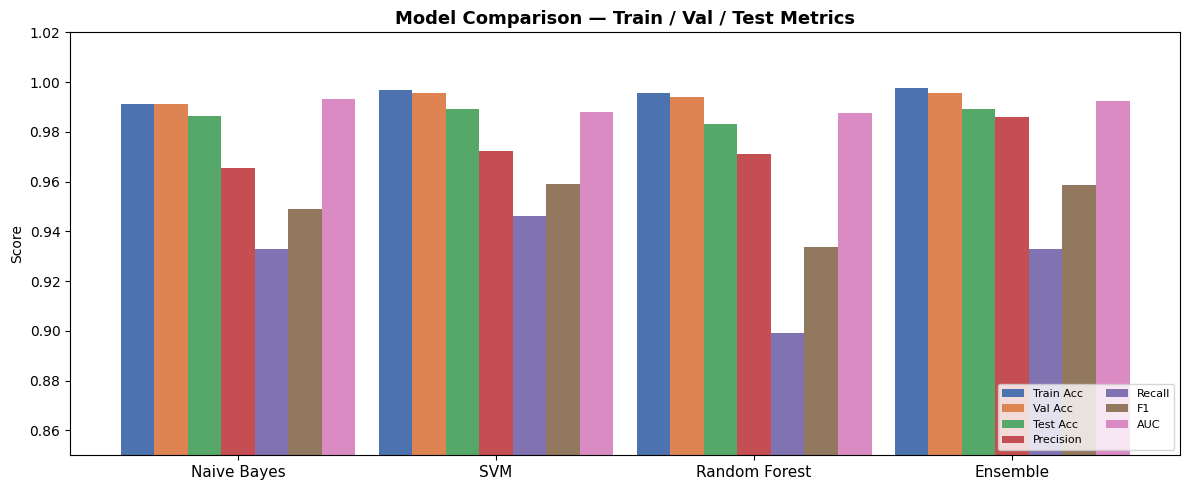

In [10]:
# 8a. Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
x  = np.arange(len(summary))
w  = 0.13
metrics_to_plot = ['Train Acc', 'Val Acc', 'Test Acc', 'Precision', 'Recall', 'F1', 'AUC']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * w, summary[metric], width=w, label=metric, color=color)

ax.set_xticks(x + w * 3)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Train / Val / Test Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


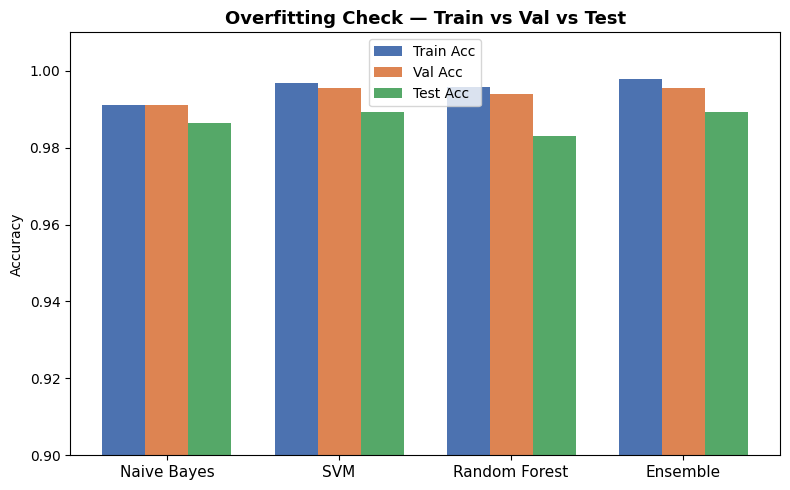

In [11]:
# 8b. Overfitting Check
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.25
x = np.arange(len(summary))
ax.bar(x - width, summary['Train Acc'], width, label='Train Acc', color='#4C72B0')
ax.bar(x,         summary['Val Acc'],   width, label='Val Acc',   color='#DD8452')
ax.bar(x + width, summary['Test Acc'],  width, label='Test Acc',  color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylim(0.9, 1.01)
ax.set_ylabel('Accuracy')
ax.set_title('Overfitting Check — Train vs Val vs Test', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('overfit_check.png', dpi=150)
plt.show()


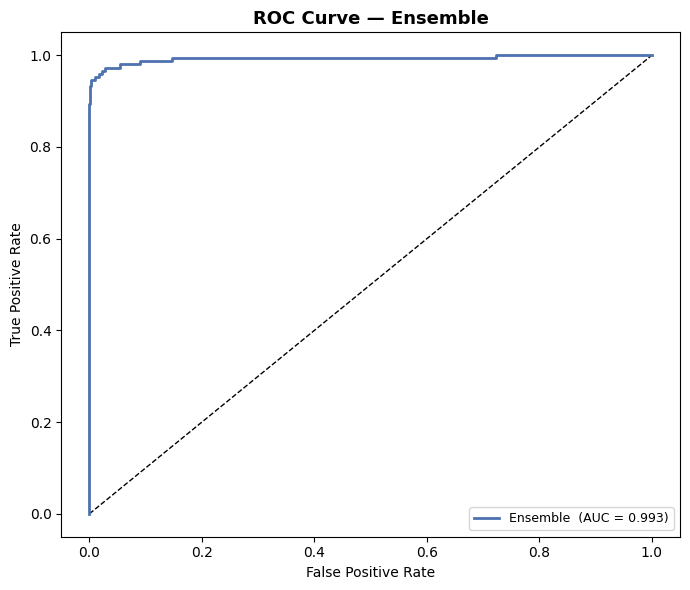

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1)

res = results['Ensemble']
fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
ax.plot(fpr, tpr, lw=2, color='#4C72B0',
        label=f"Ensemble  (AUC = {res['AUC']:.3f})")

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Ensemble', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


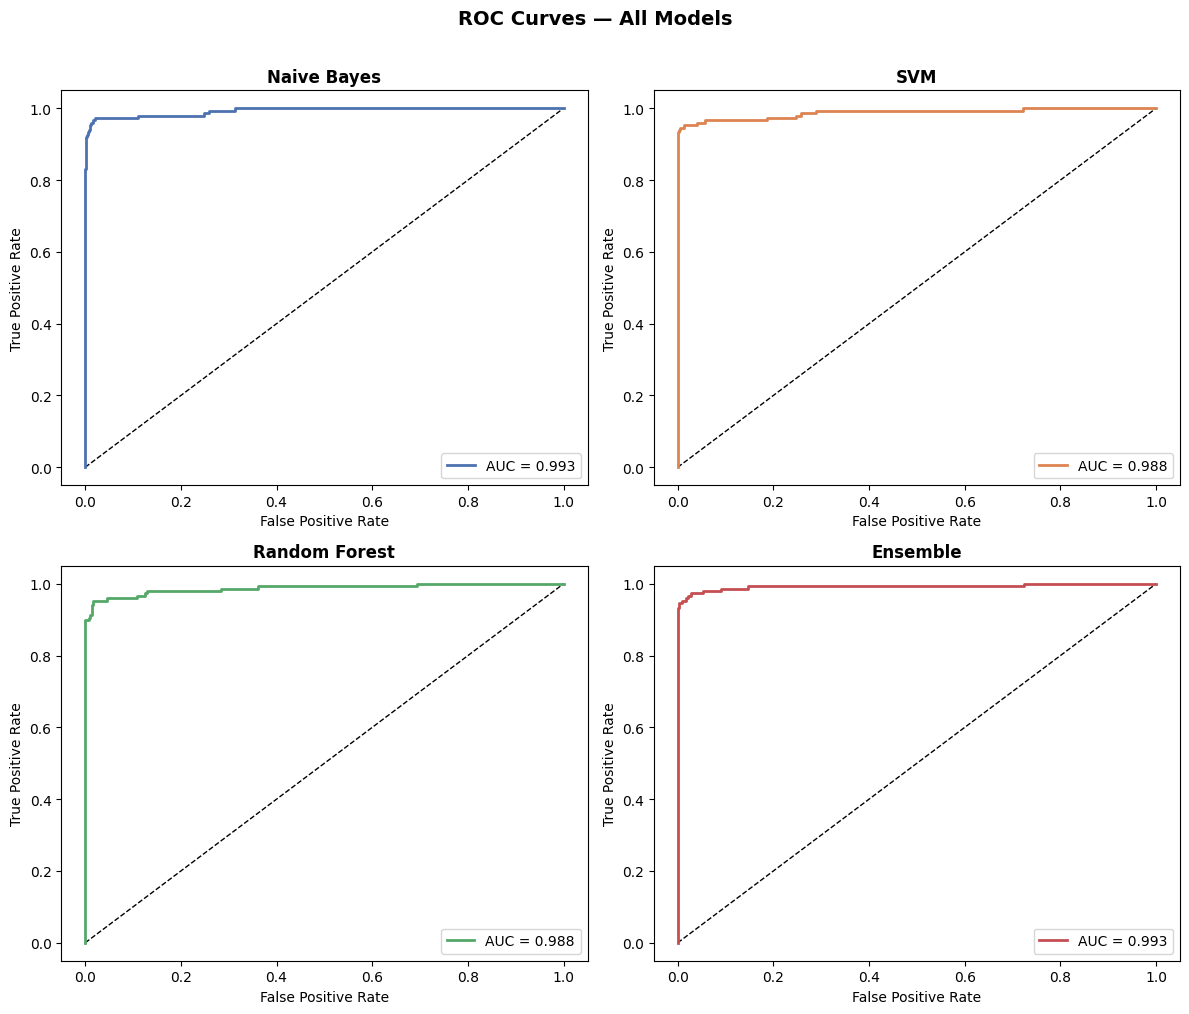

In [13]:
models = list(results.keys())  # ['Naive Bayes', 'SVM', 'Random Forest', 'Ensemble']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, name, color in zip(axes, models, colors):
    res = results[name]
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"AUC = {res['AUC']:.3f}")
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('ROC Curves — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

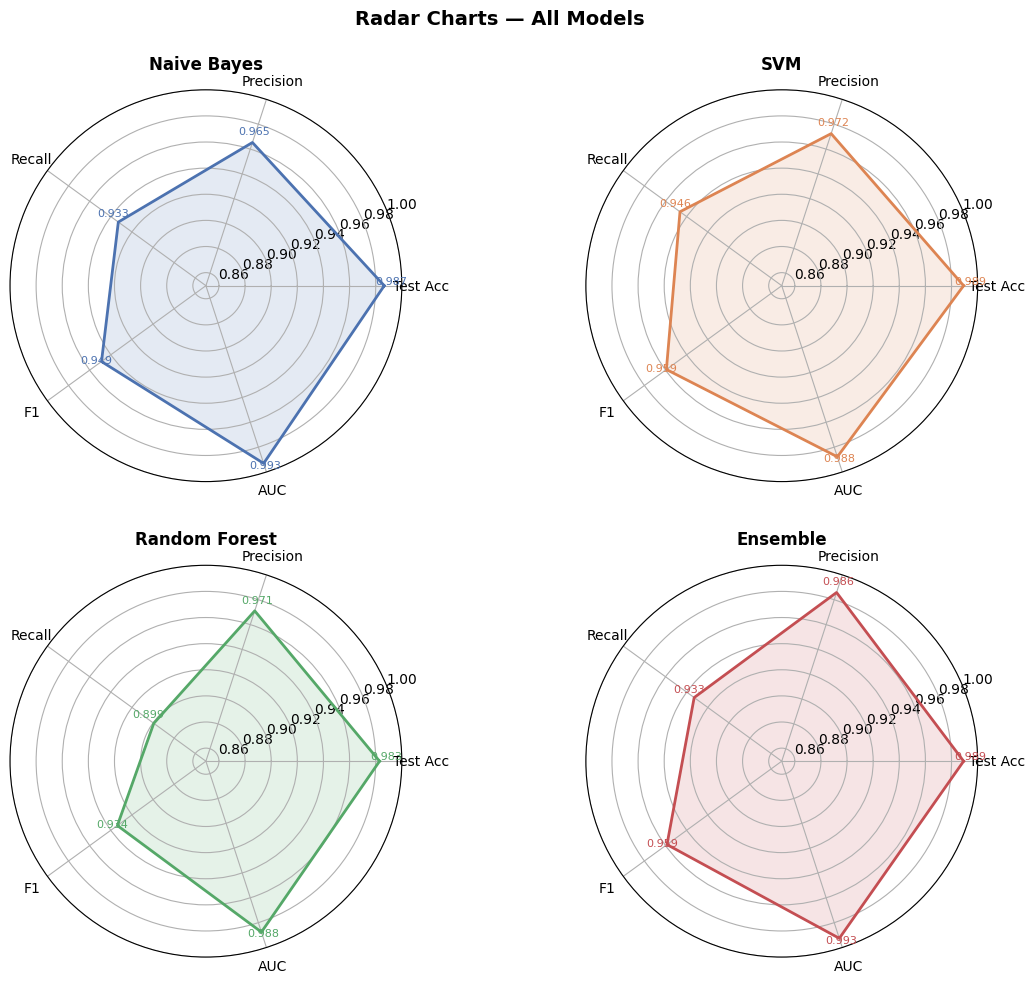

In [23]:
metrics = ['Test Acc', 'Precision', 'Recall', 'F1', 'AUC']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, (name, res), color in zip(axes, results.items(), colors):
    values = [res[m] for m in metrics] + [res[metrics[0]]]

    ax.plot(angles, values, lw=2, color=color)
    ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0.85, 1.0)
    ax.set_title(name, fontsize=12, fontweight='bold', pad=15)

    # Annotate each point with its value
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.text(angle, value + 0.005, f'{value:.3f}',
                ha='center', va='bottom', fontsize=8, color=color)

plt.suptitle('Radar Charts — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

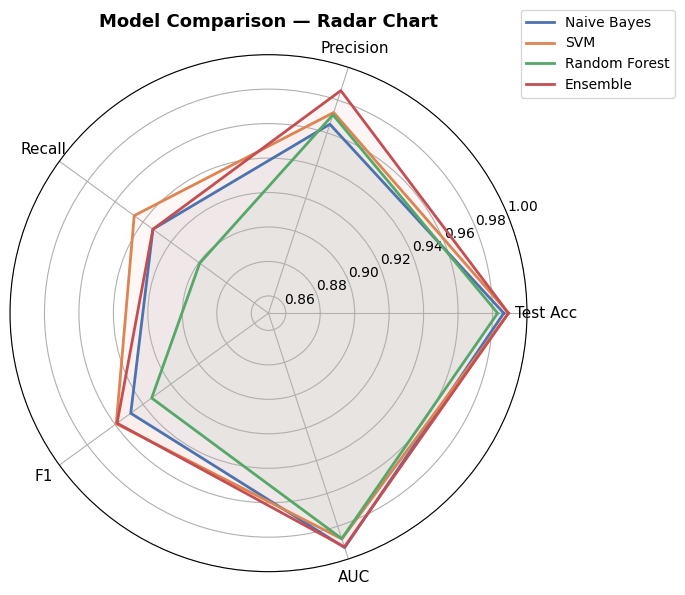

In [14]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

metrics = ['Test Acc', 'Precision', 'Recall', 'F1', 'AUC']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (name, res), color in zip(results.items(), colors):
    values = [res[m] for m in metrics] + [res[metrics[0]]]
    ax.plot(angles, values, lw=2, color=color, label=name)
    ax.fill(angles, values, color=color, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.0)
ax.set_title('Model Comparison — Radar Chart', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

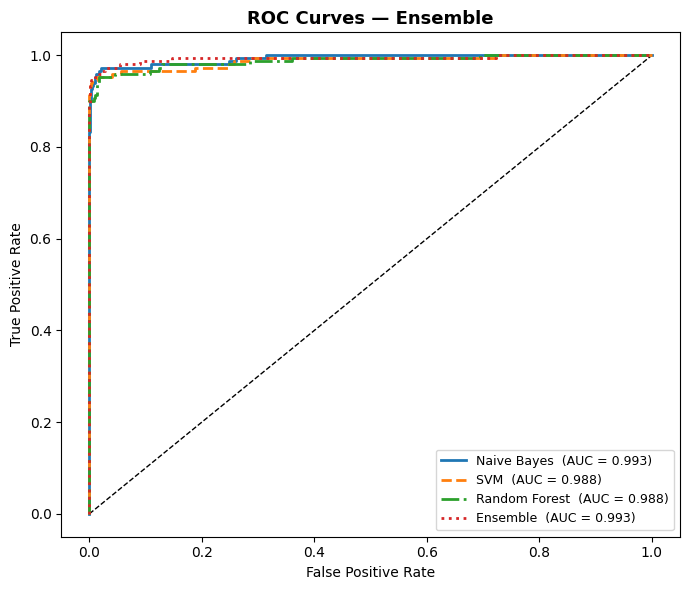

In [15]:
# 8c. ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1)
for (name, res), ls in zip(results.items(), ['-', '--', '-.', ':']):
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, lw=2, linestyle=ls,
            label=f"{name}  (AUC = {res['AUC']:.3f})")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Ensemble', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


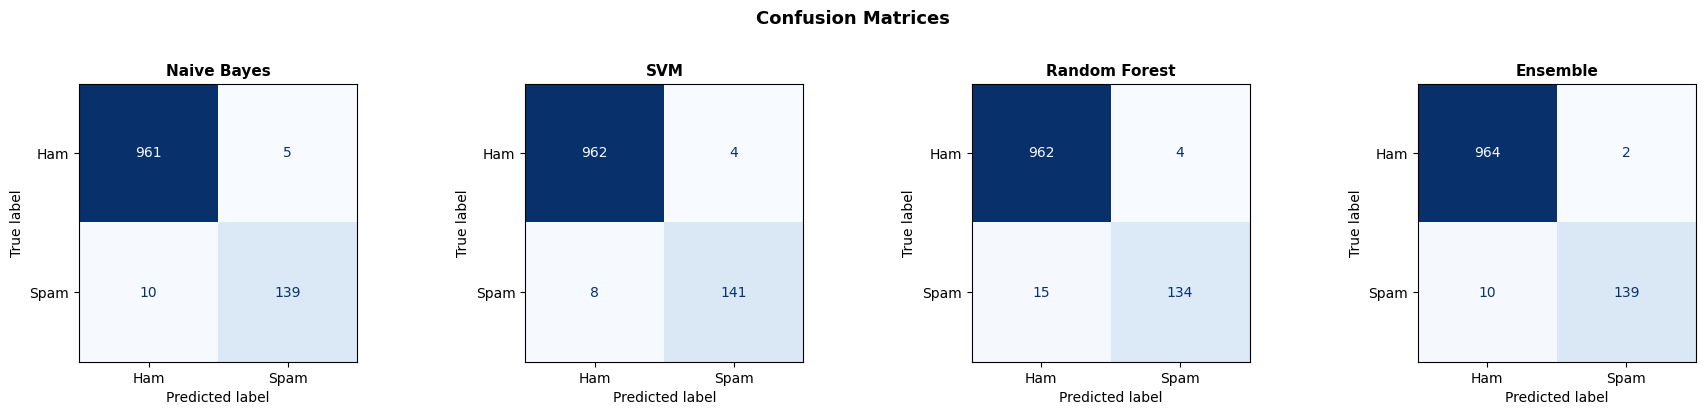

In [16]:
# 8d. Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['_y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


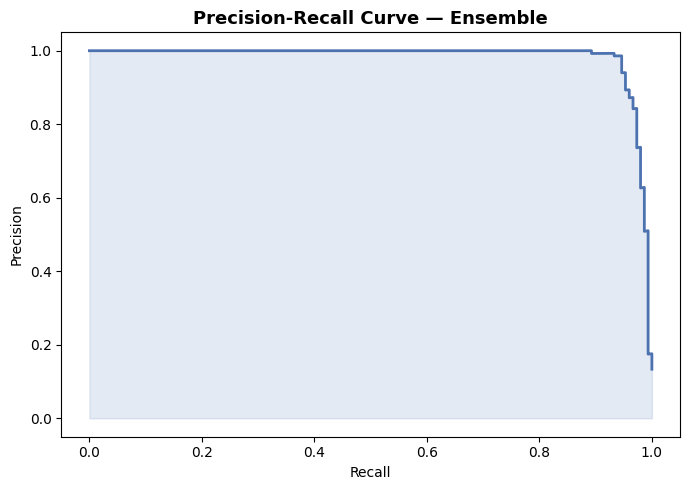

In [17]:
# 8e. Precision-Recall Curve (Ensemble)
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test, results['Ensemble']['_y_proba'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, lw=2, color='#4C72B0')
ax.fill_between(recall_curve, precision_curve, alpha=0.15, color='#4C72B0')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()


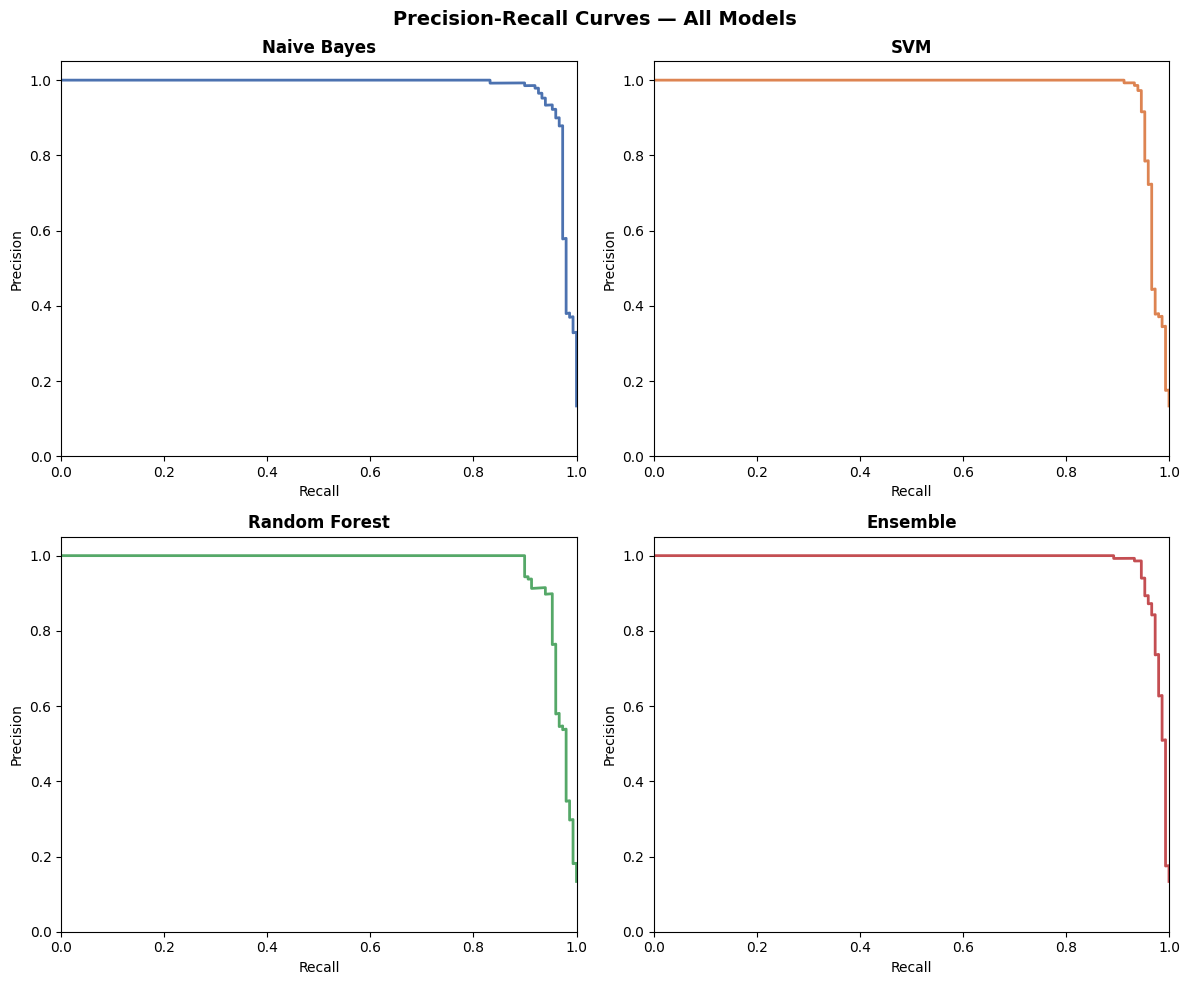

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (name, res), color in zip(axes, results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['_y_proba'])
    ax.plot(rec, prec, lw=2, color=color)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.suptitle('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

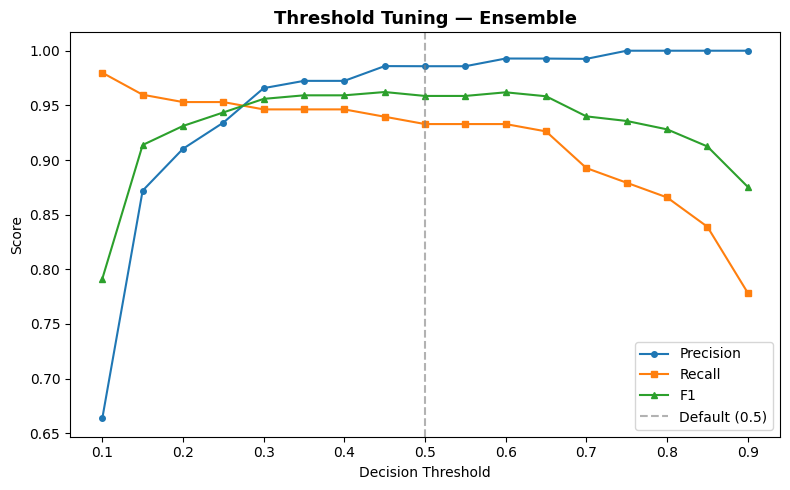

In [18]:
# 8f. Threshold Tuning
thresholds = np.arange(0.1, 0.91, 0.05)
th_precision, th_recall, th_f1 = [], [], []
for t in thresholds:
    preds = (results['Ensemble']['_y_proba'] > t).astype(int)
    th_precision.append(precision_score(y_test, preds, zero_division=0))
    th_recall.append(recall_score(y_test, preds, zero_division=0))
    th_f1.append(f1_score(y_test, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, th_precision, label='Precision', marker='o', ms=4)
ax.plot(thresholds, th_recall,    label='Recall',    marker='s', ms=4)
ax.plot(thresholds, th_f1,        label='F1',        marker='^', ms=4)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning — Ensemble', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()


## 9. Classification Reports

In [19]:
for name, res in results.items():
    print(f"\n{'='*45}\n {name}\n{'='*45}")
    print(classification_report(y_test, res['_y_pred'], target_names=['Ham', 'Spam']))



 Naive Bayes
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115


 SVM
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115


 Random Forest
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98     

## 10. Save Artifacts

In [20]:
import pickle

best_name = max(
    {k: v for k, v in results.items() if k != 'Ensemble'},
    key=lambda k: results[k]['F1']
)
print(f'\nBest base model : {best_name}  (F1 = {results[best_name]["F1"]:.4f})')
print(f'Ensemble        (F1 = {results["Ensemble"]["F1"]:.4f})')

with open('spam_model.pkl', 'wb') as f:
    pickle.dump(ensemble, f)
with open('make_df.pkl', 'wb') as f:
    pickle.dump(make_df, f)

print('\n✅ Artifacts saved: spam_model.pkl, make_df.pkl')



Best base model : SVM  (F1 = 0.9592)
Ensemble        (F1 = 0.9586)

✅ Artifacts saved: spam_model.pkl, make_df.pkl


## 11. Inference Demo

In [21]:
def predict_message(text: str, threshold: float = 0.5) -> dict:
    """Return spam probability and label for a raw SMS string."""
    clean = preprocess(text)
    row_df = pd.DataFrame([[
        clean,
        len(clean),
        len(clean.split()),
        keyword_score(text),
        caps_ratio(text),
        exclamation_count(text),
        has_url(text),
        has_phone(text),
    ]], columns=['text'] + NUM_FEATURES)
    prob  = ensemble.predict_proba(row_df)[0, 1]
    label = 'SPAM' if prob >= threshold else 'HAM'
    return {'label': label, 'spam_prob': round(float(prob), 4)}

demo_messages = [
    'Congratulations! You\'ve won a FREE iPhone. Call now to claim your prize!',
    'Hey, are we still on for dinner tomorrow at 7?',
    'URGENT: Your account has been compromised. Click here immediately.',
    'Can you pick up milk on the way home?',
    'WIN £1000 cash! Text WIN to 80086 NOW. Ends midnight!',
    'Your Netflix subscription has been suspended. Verify your info at http://netflix-secure.com',
]

print(f"{'Label':<6}  {'Prob':>6}  Message")
print('-' * 70)
for msg in demo_messages:
    r = predict_message(msg)
    print(f"[{r['label']:4s}]  {r['spam_prob']:>5.2%}  {msg[:55]}")


Label     Prob  Message
----------------------------------------------------------------------
[SPAM]  88.95%  Congratulations! You've won a FREE iPhone. Call now to 
[HAM ]  1.79%  Hey, are we still on for dinner tomorrow at 7?
[SPAM]  58.16%  URGENT: Your account has been compromised. Click here i
[HAM ]  1.88%  Can you pick up milk on the way home?
[SPAM]  91.30%  WIN £1000 cash! Text WIN to 80086 NOW. Ends midnight!
[SPAM]  83.61%  Your Netflix subscription has been suspended. Verify yo
